In [1]:
import sys
import os

running_path = "/Odyssey/private/o23gauvr/code/"
os.chdir(running_path)
sys.path.insert(0,running_path)
sys.path.insert(0, "/Odyssey/private/o23gauvr/code/FASCINATION")
#from FASCINATION.src.autoencoder_datamodule_good_split import AEDatamodule

import subprocess
import numpy as np
import xarray as xr
from pathlib import Path
import pickle
import torch
import torch.nn as nn
from MLIC.MLIC.models import MLICPlusPlus
from MLIC.MLIC.utils.utils import Config
from pathlib import Path
import shutil


from FASCINATION.src.utils import unorm_ssp_arr_3D



# Functions

In [2]:


def parse_experiment_config(ckpt_path):
    """
    Parse experiment_config.log file to extract N and M values.
    
    Args:
        ckpt_path (str): PosixPath to checkpoint 
        
    Returns:
        tuple: (N, M) values or (None, None) if parsing fails
    """

    config_file = list((ckpt_path.parent.parent).rglob("train_*.log")) 
    if not config_file:
        print(f"Warning: train logs not found in {ckpt_path}")
        return None, None
    
    config_file = config_file[0]  # Get the first match if multiple found

    try:
        with open(config_file, 'r') as f:
            content = f.read()
        
        # Extract N and M values from MODEL CONFIGURATION section
        N, M = None, None
        
        lines = content.split('\n')

        cfg = eval((lines[1].strip().split("INFO: ")[-1]).replace("<class 'torch.nn.modules.activation.","nn.").replace("'>",""))


        return cfg
        
            
    except Exception as e:
        print(f"Error parsing config file in {ckpt_path}: {e}")
        return None




In [3]:
def lon_distance_meters(lat, lon1, lon2):
    """
    Compute distance in meters between two longitudes at a given latitude.
    
    Args:
        lat: latitude in degrees
        lon1, lon2: longitudes in degrees
        
    Returns:
        Distance in meters
    """
    R = 6_371_000  # Earth radius in meters
    lat_rad = np.radians(lat)
    dlon_rad = np.radians(lon2 - lon1)
    
    distance = R * np.cos(lat_rad) * np.abs(dlon_rad)
    return distance

In [4]:


def create_ramgeo_config(title, ssp_profile, depth_array, 
                         r_update=0, 
                         freq=500, source_depth=3.0, receiver_depth=300.0,
                         rmax=10000.0, dr=10.0, ndr=1,
                         zmax=2000.0, dz=1.0, ndz=1, zmplt=1000.0,
                         c0=1500.0, n_pade=6, ns=0, rs=0.0):
    """Create RAMGEO config from SSP profile."""
    


    r = 0.0

    config = f"""{title}
{freq} {source_depth} {receiver_depth}	Frequency (Hz), source depth (m), receiver depth(s) (m)   
{rmax}	{dr} {ndr}	Max range (m), range step dr (m) range decimation
{zmax}	{dz} {ndz} {zmplt}	Max depth (m), depth step dz (m), depth decimation, depth for plotting (m)
{c0}	{n_pade} {ns} {rs}	Reference sound speed (m/s) Number of Padé terms, number of stability constraints in Pade approximation, Range of starter (0 means standard point source starter)
0.0	{2*zmax}	bathymetry data r,z in [m, m]
{rmax}	{2*zmax}
-1	-1
"""
#     config = f"""{title}
# {freq} {source_depth} {receiver_depth}    freq zs zr
# {rmax} {dr} {ndr}      rmax dr ndr
# {zmax} {dz} {ndz} {zmplt}     zmax dz ndz zmplt
# {c0} {n_pade} {ns}     c0 np ns rs 
# 0.0 {2*zmax}    rb zb 
# {rmax} {2*zmax} rb zb 
# -1 -1
# """
    # Add SSP profile
    assert ssp_profile.shape[0] == len(depth_array), "SSP profile and depth array must have the same length."

    if len(ssp_profile.shape) == 1:
        ssp_profile = np.expand_dims(ssp_profile,axis=-1)

    for j in range(ssp_profile.shape[1]):
        if j>0:
            config += f"{r}	!update profile\n"


        for i, (z, c) in enumerate(zip(depth_array, ssp_profile[:,j])):
            if i == 0:
                config += f"{z:.2f}	{c:.2f}	SSP profile (depth, sound speed)\n"
            else:
                config += f"{z:.2f}	{c:.2f}\n"

        config += """-1	-1 
0.0	1800.0	compressive sound speed profile in substrate {z,cbp} [m, m/s]
100.0   1800.0
-1	-1
0.0	1.7	density profile in substrate {z,rho} [m, g/cm³]
100.0   1.7
-1	-1
0.0	0.4	compressive attenuation profile  {z,attnp} [m, dB/lambda]
10.0    0.4
100.0	10.0    buffer layer with totam attenuation
-1	-1
"""

        r+= r_update
        if r>rmax:
            break



    output_path = f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/config/{title.replace(' ', '_')}.in"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    with open(output_path, 'w') as f:
        f.write(config)
    
    return output_path



#config_path = create_ramgeo_config("test_rad", ssp_ae_rad, depth_array,r_update=3000)


# Load data

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [6]:
data_path = "/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_196_256_good_split.pkl"
with open(data_path, 'rb') as f:
    dm = pickle.load(f)

In [7]:
ssp_da = dm.test_ds.input
depth_array = ssp_da.z.values
test_norm = ssp_da.attrs['norm_stats']
season_idx = dm.test_ds.input.season_idx
sst_test_norm  = dm.test_ds.input.attrs['sst'].data


In [8]:
# Select profile near source location
ssp_truth = ssp_da.values
ssp_truth = unorm_ssp_arr_3D(ssp_truth, test_norm)



In [9]:
cr = "10000"
ckpt_file = list(Path("/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/eusipco/MLIC/SSP").glob(f"fixed_weight_loss_64_96_1.0_CR_{cr}.0*/**/*_rmse.pth.tar"))[0]
cfg = parse_experiment_config(ckpt_file)
N = cfg.get('N', 192)
M = cfg.get('M', 320)
ssp_config = Config({
    'N': N, 'M': M, 'slice_num': cfg.get('slice_num', 10),
    'context_window': cfg.get('context_window', 5), 'act': cfg.get('act', nn.GELU),
    'in_channels': cfg.get('in_channels', 157), 'out_channels': cfg.get('in_channels', 157), 
    "add_seasons": cfg.get("add_seasons", {"use": False, "mode": None}),
    "add_sst": cfg.get("add_sst", False)
})

try:
    cr = str(ckpt_file).split("CR_")[-1].split("_")[0]
except:
    cr = ""



        

In [10]:
try:
    net = MLICPlusPlus(config=ssp_config).eval().to(device)
    ck = torch.load(ckpt_file, map_location=device)
    if "one_hot_old" in str(ckpt_file) or str(ckpt_file) == "/Odyssey/private/o23gauvr/code/MLIC/experiments/full_loss_batch_4_add_season_hot_one_64_96_0.0018_min_max/20251001_001608/checkpoints/checkpoint_best_loss.pth.tar":
        del ck['state_dict']["season_embed.weight"]
    net.load_state_dict(ck['state_dict'])


    test_norm = ck.get('test_norm_stats', None)
    test_norm_method = test_norm['method']

    
    if test_norm_method == "min_max":
        x_min = test_norm["params"]["x_min"].astype(ssp_truth.dtype)
        x_max = test_norm["params"]["x_max"].astype(ssp_truth.dtype)    
        ssp_truth = (ssp_truth - x_min) / (x_max - x_min)
    elif test_norm_method == "mean_std":
        mean = test_norm['params']["mean"].astype(ssp_truth.dtype)
        std = test_norm['params']["std"].astype(ssp_truth.dtype)
        ssp_truth = (ssp_truth - mean) / std
    elif test_norm_method == "mean_std_along_depth":
        mean = test_norm['params']["mean_along_depth"].astype(ssp_truth.dtype)
        std = test_norm['params']["std_along_depth"].astype(ssp_truth.dtype)
        ssp_truth = (ssp_truth - mean) / std

except Exception as e:
    print(f"Error loading model or normalizing data: {e}")



/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538435607/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/tmp/ipykernel_1365180/1695475165.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mod

In [11]:

ssp_truth_tens = torch.tensor(ssp_truth).to(device=device, dtype=getattr(torch,dm.dtype_str))
with torch.no_grad():
    rv_batch = net(ssp_truth_tens, season_idx, sst_test_norm)

ssp_ae = rv_batch['x_hat'].detach().cpu().numpy()

ssp_ae = unorm_ssp_arr_3D(ssp_ae, test_norm)
ssp_truth = unorm_ssp_arr_3D(ssp_truth, test_norm)


# Run models random profiles

In [12]:
t,lat,lon = 10,10,10

In [13]:
ssp_ae_profile = ssp_ae[t,:, lat, lon]  # Select profile at lat=100, lon=100

ssp_truth_profile = ssp_truth[t,:, lat, lon]

## Truth

In [14]:


prof = ssp_truth_profile
title = f"RAMGEO_SSP_TRUTH"


config_path_truth = create_ramgeo_config(title, prof, depth_array)
xp_truth = config_path_truth.split("/")[-1].split(".")[0]

In [15]:
# Run RAMGEO simulation and post-processing for current experiment
truth_dir = f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}"

# Copy template results directory

if os.path.exists(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}"):
    shutil.rmtree(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}")
shutil.copytree("/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/results", truth_dir)

'/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH'

In [16]:
# Run RAMGEO
subprocess.run([
    '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo',
    f'--input={config_path_truth}',
    f'--output-dir={truth_dir}'
])

Frequency:   500.00 Hz
Wavelength:     3.00 m
Depth step dz:    1.000 m [fixed - original compatibility]
Range step dr:   10.000 m [fixed - original compatibility]
  dz/wavelength =    0.333 (should be < 0.1 for accuracy)
  dr/wavelength =    3.333 (should be < 0.5 for accuracy)

Number of receiver depths: 1
  Receiver 1: depth =   300.00 m, index = 301

CPU time (RAM run):      0.159 s


CompletedProcess(args=['/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo', '--input=/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/config/RAMGEO_SSP_TRUTH.in', '--output-dir=/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH'], returncode=0)

In [17]:
# Plot results
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py',
    '--data-dir', truth_dir
])

RAM Acoustic Model - Result Plotter

Reading input parameters...
  Parameters read from output file headers
  Frequency: 500.0 Hz
  Source depth: 3.0 m
  Receiver depths: 300.0 m (1 receivers)
  Max range: 10000.0 m
  Range step (dr): 10.000000 m
  Range decimation (ndr): 1
  Depth step (dz): 1.000000 m
  Depth decimation (ndz): 1
  Plot depth limit (zmplt): 1000.0 m

Reading output files...
  TL line: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH/tl.line
  TL grid: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH/tl.grid
  P grid: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH/p.grid

Determining grid size for automatic subsampling...
  Grid dimensions: 999 depth × 1000 range points
  Auto-calculated range subsampling: 1:1 (1000 → 1000 points)
  Auto-calculated depth subsampling: 1:1 (999 → 999 points)

Final subsampling: Range 1:1, Depth 1:1
(Range subsampling occurs while reading files; depth subsampl

CompletedProcess(args=['python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py', '--data-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH'], returncode=0)

## AE

In [18]:

prof = ssp_ae_profile
title = f"RAMGEO_REC_CR_{cr}"


config_path_ae = create_ramgeo_config(title, prof, depth_array)
xp_ae = config_path_ae.split("/")[-1].split(".")[0]

print(f"Config for RAMGEO AE created at: {config_path_ae}")

Config for RAMGEO AE created at: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/config/RAMGEO_REC_CR_10000.0.in


In [19]:
# Run RAMGEO simulation and post-processing for current experiment
ae_dir = f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}"

# Copy template results directory

if os.path.exists(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}"):
    shutil.rmtree(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}")
shutil.copytree("/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/results", ae_dir)

'/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000'

In [20]:
# Run RAMGEO
subprocess.run([
    '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo',
    f'--input={config_path_ae}',
    f'--output-dir={ae_dir}'
])

Frequency:   500.00 Hz
Wavelength:     3.00 m
Depth step dz:    1.000 m [fixed - original compatibility]
Range step dr:   10.000 m [fixed - original compatibility]
  dz/wavelength =    0.333 (should be < 0.1 for accuracy)
  dr/wavelength =    3.333 (should be < 0.5 for accuracy)

Number of receiver depths: 1
  Receiver 1: depth =   300.00 m, index = 301

CPU time (RAM run):      0.158 s


CompletedProcess(args=['/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo', '--input=/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/config/RAMGEO_REC_CR_10000.0.in', '--output-dir=/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000'], returncode=0)

In [21]:
# Plot results
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py',
    '--data-dir', ae_dir
])

RAM Acoustic Model - Result Plotter

Reading input parameters...
  Parameters read from output file headers
  Frequency: 500.0 Hz
  Source depth: 3.0 m
  Receiver depths: 300.0 m (1 receivers)
  Max range: 10000.0 m
  Range step (dr): 10.000000 m
  Range decimation (ndr): 1
  Depth step (dz): 1.000000 m
  Depth decimation (ndz): 1
  Plot depth limit (zmplt): 1000.0 m

Reading output files...
  TL line: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000/tl.line
  TL grid: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000/tl.grid
  P grid: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000/p.grid

Determining grid size for automatic subsampling...
  Grid dimensions: 999 depth × 1000 range points
  Auto-calculated range subsampling: 1:1 (1000 → 1000 points)
  Auto-calculated depth subsampling: 1:1 (999 → 999 points)

Final subsampling: Range 1:1, Depth 1:1
(Range subsampling occurs while reading files; depth

CompletedProcess(args=['python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py', '--data-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000'], returncode=0)

## Differences

In [22]:
# Compute differences with truth
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py',
    '--rec-dir', ae_dir,
    '--truth-dir', truth_dir,
    '--output-dir', "/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/"
])

RAMGEO Difference Analysis Tool

REC directory:    /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000
TRUTH directory:  /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH
Output directory: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000

Reading parameters from: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/config/RAMGEO_SSP_TRUTH_DECILE_0_t_49_lat_59_lon_151.in
  Frequency: 500.0 Hz
  Source depth: 3.0 m

Computing Differences

Processing TL line files...
  Receiver 1: Mean diff = 4.0077 dB, Max diff = 27.5045 dB
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/tl_diff.line

Processing TL grid files...
  Grid shape: (999, 1000)
  Mean diff: nan dB
  Max diff: nan dB
  Median diff: nan dB
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/tl_diff.grid

Processing pressure grid files...
  Grid shape: (999, 1000)
  Complex di

/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py:350: RuntimeWarning: invalid value encountered in subtract
  tl_diff_grid = np.abs(rec_tl_grid - truth_tl_grid)


  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/p_diff.grid

Saved statistics: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/diff_statistics.txt

Generating Plots
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/figures/tl_diff_vs_range.png
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/figures/tl_diff_field.png
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/figures/pressure_diff_field.png


/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/figures/difference_summary.png

Analysis Complete!

Output files saved to: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000

Generated files:
  - tl_diff.line
  - tl_diff.grid
  - p_diff.grid
  - diff_statistics.txt
  - figures/tl_diff_vs_range.png
  - figures/tl_diff_field.png
  - figures/pressure_diff_field.png
  - figures/difference_summary.png


CompletedProcess(args=['python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py', '--rec-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000', '--truth-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH', '--output-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/'], returncode=0)

# Profiles per decile

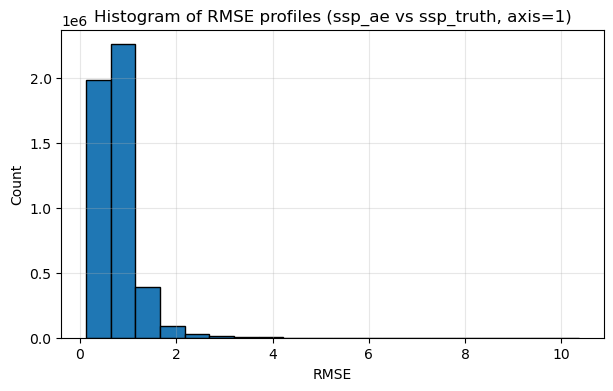

In [23]:
import matplotlib.pyplot as plt

# RMSE along 2nd dimension (axis=1, typically depth)
rmse_depth = np.sqrt(np.nanmean((ssp_ae - ssp_truth) ** 2, axis=1))

# Histogram with 20 bins (flatten all remaining dimensions)
plt.figure(figsize=(7, 4))
plt.hist(rmse_depth.ravel(), bins=20, edgecolor="black")
plt.xlabel("RMSE")
plt.ylabel("Count")
plt.title("Histogram of RMSE profiles (ssp_ae vs ssp_truth, axis=1)")
plt.grid(alpha=0.3)
plt.show()

In [24]:
ssp_truth_da = ssp_da.copy(data=ssp_truth)
ssp_ae_da = ssp_da.copy(data=ssp_ae)

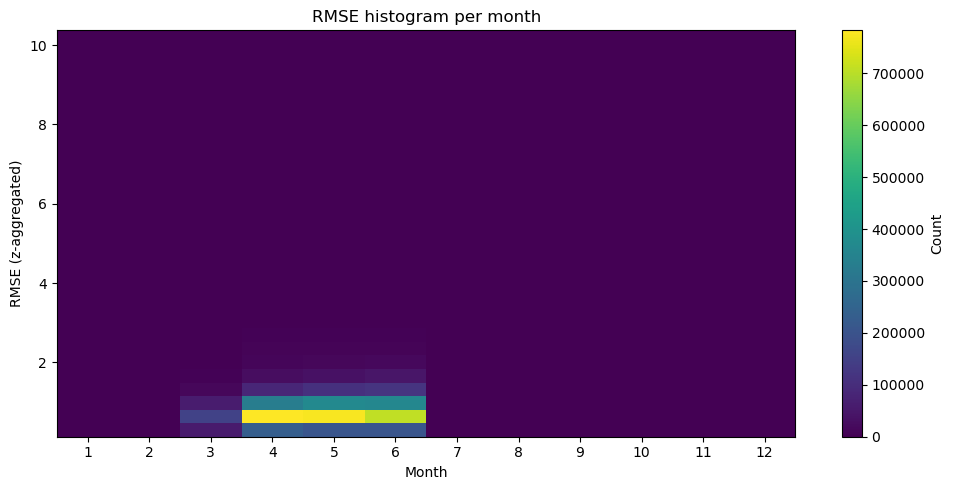

In [25]:
# RMSE along z (keeps dims: time, lat, lon)
rmse_z = np.sqrt(((ssp_ae_da - ssp_truth_da) ** 2).mean(dim="z", skipna=True))

month_idx = rmse_z["time"].dt.month.values
rmse_vals = rmse_z.values  # shape: (time, lat, lon)

# RMSE bins
valid = np.isfinite(rmse_vals)
rmse_min = np.nanmin(rmse_vals[valid])
rmse_max = np.nanmax(rmse_vals[valid])
bins = np.linspace(rmse_min, rmse_max, 31)

# Histogram count per month
hist_per_month = np.zeros((len(bins) - 1, 12), dtype=int)
for m in range(1, 13):
    mask_t = month_idx == m
    vals_m = rmse_vals[mask_t, ...].ravel()
    vals_m = vals_m[np.isfinite(vals_m)]
    hist_per_month[:, m - 1], _ = np.histogram(vals_m, bins=bins)

# Colormesh: months on x, RMSE on y, count as color
month_edges = np.arange(0.5, 13.5, 1.0)  # 12 month bins -> 13 edges

plt.figure(figsize=(10, 5))
pcm = plt.pcolormesh(month_edges, bins, hist_per_month, shading="auto")
plt.xlim(0.5, 12.5)
plt.xticks(np.arange(1, 13))
plt.xlabel("Month")
plt.ylabel("RMSE (z-aggregated)")
plt.title("RMSE histogram per month")
cbar = plt.colorbar(pcm)
cbar.set_label("Count")
plt.tight_layout()
plt.show()

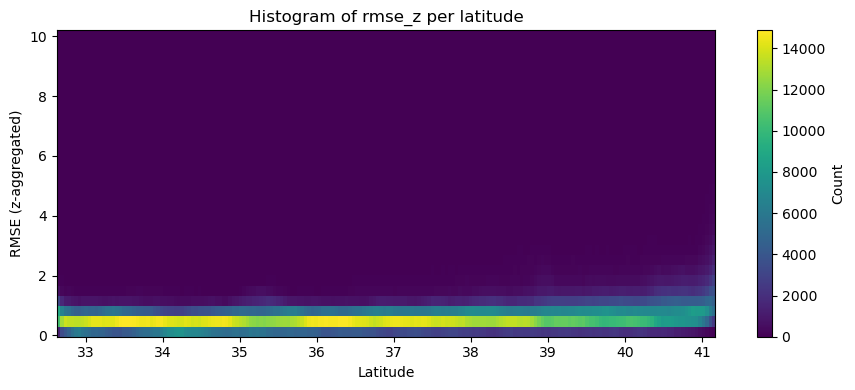

In [26]:
# Histogram of rmse_z per latitude coordinate (time/lon collapsed)
rmse_vals = rmse_z.values  # expected shape: (time, lat, lon)
lat_vals = rmse_z["lat"].values

# RMSE bins
rmse_min = np.nanmin(rmse_vals)
rmse_max = np.nanmax(rmse_vals)
bins = np.linspace(rmse_min, rmse_max, 31)

# Count histogram per latitude
hist_per_lat = np.zeros((len(lat_vals), len(bins) - 1), dtype=int)
for i in range(len(lat_vals)):
    vals_i = rmse_vals[:, i, :].ravel()
    vals_i = vals_i[np.isfinite(vals_i)]
    hist_per_lat[i], _ = np.histogram(vals_i, bins=bins)

# Plot as 2D histogram heatmap
plt.figure(figsize=(9, 4))
plt.pcolormesh(lat_vals, bins[:-1], hist_per_lat.T, shading="auto")
plt.xlabel("Latitude")
plt.ylabel("RMSE (z-aggregated)")
plt.title("Histogram of rmse_z per latitude")
cbar = plt.colorbar()
cbar.set_label("Count")
plt.tight_layout()
plt.show()

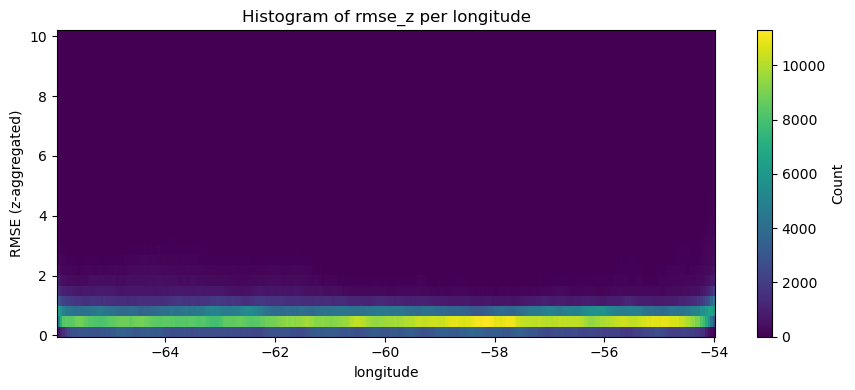

In [27]:
# Histogram of rmse_z per longitude coordinate (time/lon collapsed)
rmse_vals = rmse_z.values  # expected shape: (time, lon, lon)
lon_vals = rmse_z["lon"].values

# RMSE bins
rmse_min = np.nanmin(rmse_vals)
rmse_max = np.nanmax(rmse_vals)
bins = np.linspace(rmse_min, rmse_max, 31)

# Count histogram per longitude
hist_per_lon = np.zeros((len(lon_vals), len(bins) - 1), dtype=int)
for i in range(len(lon_vals)):
    vals_i = rmse_vals[:, :, i].ravel()
    vals_i = vals_i[np.isfinite(vals_i)]
    hist_per_lon[i], _ = np.histogram(vals_i, bins=bins)

# Plot as 2D histogram heatmap
plt.figure(figsize=(9, 4))
plt.pcolormesh(lon_vals, bins[:-1], hist_per_lon.T, shading="auto")
plt.xlabel("longitude")
plt.ylabel("RMSE (z-aggregated)")
plt.title("Histogram of rmse_z per longitude")
cbar = plt.colorbar()
cbar.set_label("Count")
plt.tight_layout()
plt.show()

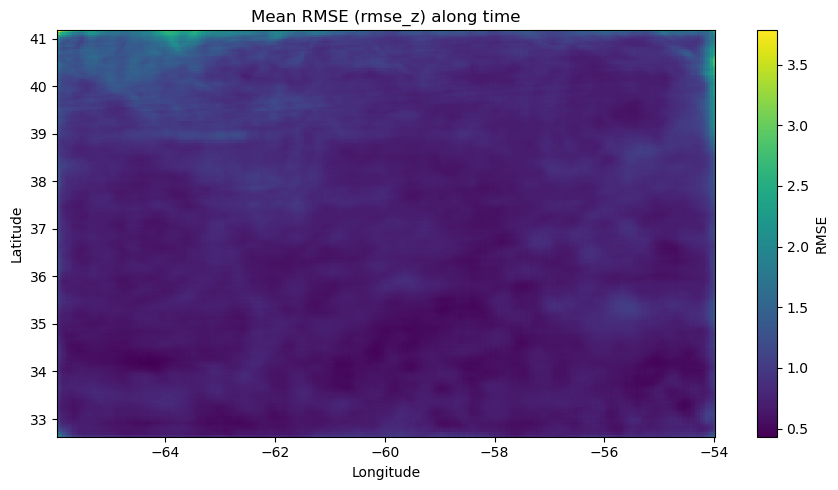

In [28]:
rmse_z_mean_time = rmse_z.mean(dim="time", skipna=True)

lon_vals = rmse_z_mean_time["lon"].values
lat_vals = rmse_z_mean_time["lat"].values
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)

plt.figure(figsize=(9, 5))
pcm = plt.pcolormesh(lon_grid, lat_grid, rmse_z_mean_time.values, shading="auto")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mean RMSE (rmse_z) along time")
cbar = plt.colorbar(pcm)
cbar.set_label("RMSE")
plt.tight_layout()
plt.show()

In [29]:
import numpy as np

# Flatten rmse_z and get valid (non-NaN) values with indices
rmse_flat = rmse_z.values.ravel()
valid_mask = np.isfinite(rmse_flat)
valid_values = rmse_flat[valid_mask]
valid_indices = np.where(valid_mask)[0]

# Compute 10 decile thresholds: 0%, 11.1%, 22.2%, ..., 100%
percentiles = np.linspace(0, 100, 11)
thresholds = np.percentile(valid_values, percentiles)

# For each threshold, find the closest actual data point
selected_flat_indices = []
for thresh in thresholds:
    idx_in_valid = np.argmin(np.abs(valid_values - thresh))
    selected_flat_indices.append(valid_indices[idx_in_valid])

# Convert flat indices back to multi-dimensional coordinates
shape = rmse_z.shape
dim_names = rmse_z.dims
selected_points = []

for i, flat_idx in enumerate(selected_flat_indices):
    multi_idx = np.unravel_index(flat_idx, shape)
    point = {dim: int(idx) for dim, idx in zip(dim_names, multi_idx)}  # integer indices
    point['rmse_value'] = rmse_flat[flat_idx]
    point['percentile'] = percentiles[i]
    selected_points.append(point)

# Display results
import pandas as pd
df_deciles = pd.DataFrame(selected_points)
print(df_deciles)

    time  lat  lon  rmse_value  percentile
0     49   59  151    0.127389         0.0
1     30   46  152    0.430279        10.0
2     48  163  230    0.506322        20.0
3     19    3   51    0.569202        30.0
4      4  114  174    0.629891        40.0
5     34   89  127    0.693822        50.0
6     42  103  241    0.765667        60.0
7     62  162  194    0.852708        70.0
8     89  171   55    0.971644        80.0
9     44  115   68    1.186916        90.0
10    51  186  255   10.371439       100.0


In [30]:
len(ssp_da.lat),  len(ssp_da.lat),  len(ssp_da.lon),

(192, 192, 256)

In [31]:
decile = 0

In [32]:
t,lat,lon = df_deciles['time'][decile], df_deciles['lat'][decile], df_deciles['lon'][decile]
ssp_ae_profile = ssp_ae[t,:, lat, lon]  # Select profile at lat=100, lon=100

ssp_truth_profile = ssp_truth[t,:, lat, lon]
## Truth


prof = ssp_truth_profile
title = f"RAMGEO_SSP_TRUTH_DECILE_{decile}_t_{t}_lat_{lat}_lon_{lon}"


config_path_truth = create_ramgeo_config(title, prof, depth_array)
xp_truth = config_path_truth.split("/")[-1].split(".in")[0].replace(".0", "")
# Run RAMGEO simulation and post-processing for current experiment
truth_dir = f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}"

# Copy template results directory

if os.path.exists(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}"):
    shutil.rmtree(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}")
shutil.copytree("/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/results", truth_dir)
# Run RAMGEO
subprocess.run([
    '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo',
    f'--input={config_path_truth}',
    f'--output-dir={truth_dir}'
])
# Plot results
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py',
    '--data-dir', truth_dir
])
## AE

prof = ssp_ae_profile
title = f"RAMGEO_REC_CR_{cr}_DECILE_{decile}_t_{t}_lat_{lat}_lon_{lon}"


config_path_ae = create_ramgeo_config(title, prof, depth_array)
xp_ae = config_path_ae.split("/")[-1].split(".in")[0].replace(".0", "")

print(f"Config for RAMGEO AE created at: {config_path_ae}")
# Run RAMGEO simulation and post-processing for current experiment
ae_dir = f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}"

# Copy template results directory

if os.path.exists(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}"):
    shutil.rmtree(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}")
shutil.copytree("/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/results", ae_dir)
# Run RAMGEO
subprocess.run([
    '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo',
    f'--input={config_path_ae}',
    f'--output-dir={ae_dir}'
])
# Plot results
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py',
    '--data-dir', ae_dir
])
## Differences
# Compute differences with truth
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py',
    '--rec-dir', ae_dir,
    '--truth-dir', truth_dir,
    '--output-dir', "/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/"
])

Frequency:   500.00 Hz
Wavelength:     3.00 m
Depth step dz:    1.000 m [fixed - original compatibility]
Range step dr:   10.000 m [fixed - original compatibility]
  dz/wavelength =    0.333 (should be < 0.1 for accuracy)
  dr/wavelength =    3.333 (should be < 0.5 for accuracy)

Number of receiver depths: 1
  Receiver 1: depth =   300.00 m, index = 301

CPU time (RAM run):      0.236 s
RAM Acoustic Model - Result Plotter

Reading input parameters...
  Parameters read from output file headers
  Frequency: 500.0 Hz
  Source depth: 3.0 m
  Receiver depths: 300.0 m (1 receivers)
  Max range: 10000.0 m
  Range step (dr): 10.000000 m
  Range decimation (ndr): 1
  Depth step (dz): 1.000000 m
  Depth decimation (ndz): 1
  Plot depth limit (zmplt): 1000.0 m

Reading output files...
  TL line: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH_DECILE_0_t_49_lat_59_lon_151/tl.line
  TL grid: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH_DECILE

/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py:350: RuntimeWarning: invalid value encountered in subtract
  tl_diff_grid = np.abs(rec_tl_grid - truth_tl_grid)


  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_49_lat_59_lon_151/tl_diff.grid

Processing pressure grid files...
  Grid shape: (999, 1000)
  Complex diff - Mean: 6.794390e-05, Max: 3.371393e-04
  Magnitude diff - Mean: 1.321371e-05, Max: 9.981129e-05
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_49_lat_59_lon_151/p_diff.grid

Saved statistics: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_49_lat_59_lon_151/diff_statistics.txt

Generating Plots
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_49_lat_59_lon_151/figures/tl_diff_vs_range.png
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_49_lat_59_lon_151/figures/tl_diff_field.png
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_49_lat_59_lon_1

/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_49_lat_59_lon_151/figures/difference_summary.png

Analysis Complete!

Output files saved to: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_49_lat_59_lon_151

Generated files:
  - tl_diff.line
  - tl_diff.grid
  - p_diff.grid
  - diff_statistics.txt
  - figures/tl_diff_vs_range.png
  - figures/tl_diff_field.png
  - figures/pressure_diff_field.png
  - figures/difference_summary.png


CompletedProcess(args=['python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py', '--rec-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000_DECILE_0_t_49_lat_59_lon_151', '--truth-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH_DECILE_0_t_49_lat_59_lon_151', '--output-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/'], returncode=0)

# Radials per decile

## slices along lat

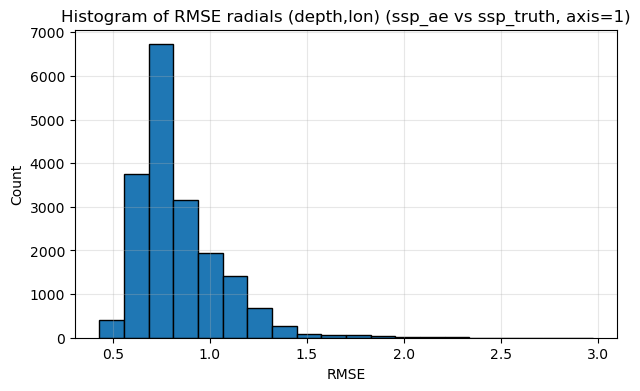

In [33]:

# RMSE along 2nd dimension (axis=1, typically depth)
rmse_depth_lon = np.sqrt(np.nanmean((ssp_ae - ssp_truth) ** 2, axis=(1,3)))

# Histogram with 20 bins (flatten all remaining dimensions)
plt.figure(figsize=(7, 4))
plt.hist(rmse_depth_lon.ravel(), bins=20, edgecolor="black")
plt.xlabel("RMSE")
plt.ylabel("Count")
plt.title("Histogram of RMSE radials (depth,lon) (ssp_ae vs ssp_truth, axis=1)")
plt.grid(alpha=0.3)
plt.show()

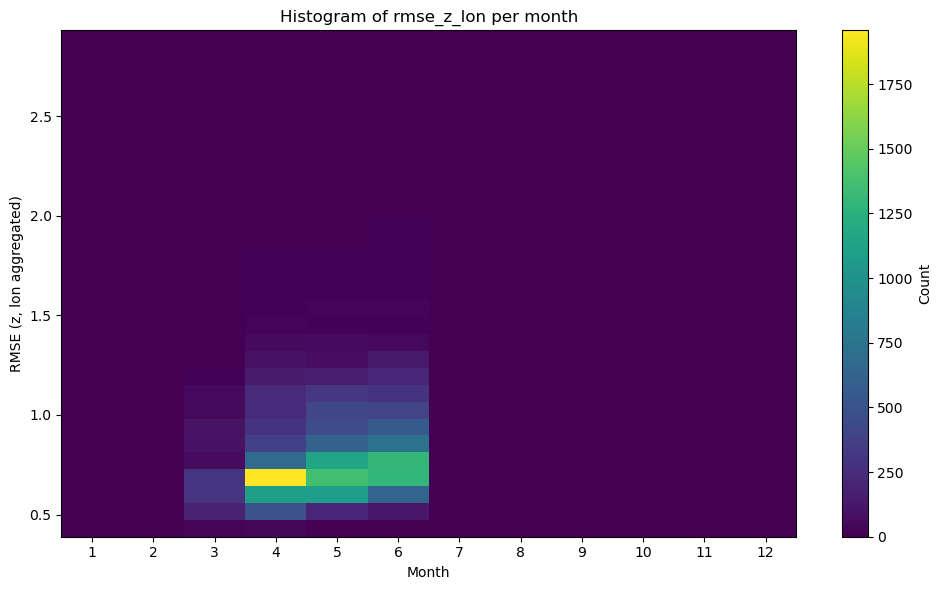

In [34]:
# RMSE along z and lon
rmse_z_lon = np.sqrt(((ssp_ae_da - ssp_truth_da) ** 2).mean(dim=("z","lon"), skipna=True))

month_idx = rmse_z_lon["time"].dt.month.values
rmse_vals = rmse_z_lon.values

# RMSE bins
rmse_min = np.nanmin(rmse_vals)
rmse_max = np.nanmax(rmse_vals)
bins = np.linspace(rmse_min, rmse_max, 31)

# Count histogram per month
hist_per_month = np.zeros((len(bins) - 1, 12), dtype=int)
for m in range(1, 13):
    mask_t = month_idx == m
    rmse_m = rmse_vals[mask_t]
    rmse_m = rmse_m[np.isfinite(rmse_m)]
    hist_per_month[:, m - 1], _ = np.histogram(rmse_m, bins=bins)

# Plot 2D histogram heatmap
plt.figure(figsize=(10, 6))
plt.pcolormesh(np.arange(1, 13), bins[:-1], hist_per_month, shading="auto")
plt.xlabel("Month")
plt.ylabel("RMSE (z, lon aggregated)")
plt.title("Histogram of rmse_z_lon per month")
plt.xticks(np.arange(1, 13))
cbar = plt.colorbar()
cbar.set_label("Count")
plt.tight_layout()
plt.show()

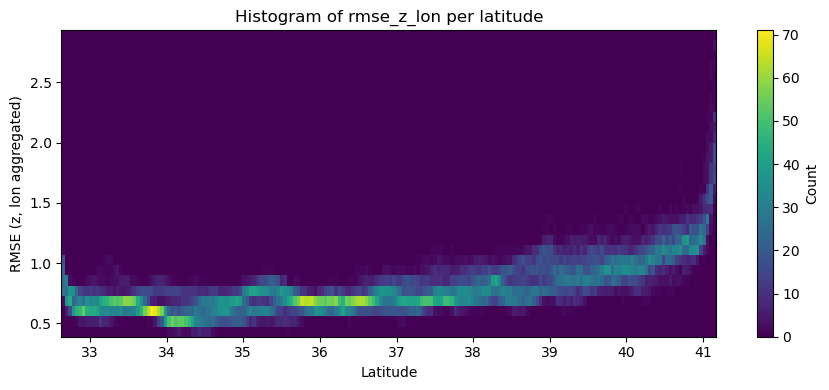

In [35]:
# Histogram of rmse_z_lon per latitude (time collapsed)
rmse_vals = rmse_z_lon.values  # expected dims: (time, lat)
lat_vals = rmse_z_lon["lat"].values

# RMSE bins from valid values
valid = np.isfinite(rmse_vals)
rmse_min = np.nanmin(rmse_vals[valid])
rmse_max = np.nanmax(rmse_vals[valid])
bins = np.linspace(rmse_min, rmse_max, 31)

# Count histogram per latitude
hist_per_lat = np.zeros((len(lat_vals), len(bins) - 1), dtype=int)
for i in range(len(lat_vals)):
    vals_i = rmse_vals[:, i]
    vals_i = vals_i[np.isfinite(vals_i)]
    hist_per_lat[i], _ = np.histogram(vals_i, bins=bins)

# Plot 2D histogram heatmap
plt.figure(figsize=(9, 4))
plt.pcolormesh(lat_vals, bins[:-1], hist_per_lat.T, shading="auto")
plt.xlabel("Latitude")
plt.ylabel("RMSE (z, lon aggregated)")
plt.title("Histogram of rmse_z_lon per latitude")
cbar = plt.colorbar()
cbar.set_label("Count")
plt.tight_layout()
plt.show()

In [36]:
import numpy as np

# Flatten rmse_z and get valid (non-NaN) values with indices
rmse_flat = rmse_z_lon.values.ravel()
valid_mask = np.isfinite(rmse_flat)
valid_values = rmse_flat[valid_mask]
valid_indices = np.where(valid_mask)[0]

# Compute 10 decile thresholds: 0%, 11.1%, 22.2%, ..., 100%
percentiles = np.linspace(0, 100, 11)
thresholds = np.percentile(valid_values, percentiles)

# For each threshold, find the closest actual data point
selected_flat_indices = []
for thresh in thresholds:
    idx_in_valid = np.argmin(np.abs(valid_values - thresh))
    selected_flat_indices.append(valid_indices[idx_in_valid])

# Convert flat indices back to multi-dimensional coordinates
shape = rmse_z_lon.shape
dim_names = rmse_z_lon.dims
selected_points = []

for i, flat_idx in enumerate(selected_flat_indices):
    multi_idx = np.unravel_index(flat_idx, shape)
    point = {dim: int(idx) for dim, idx in zip(dim_names, multi_idx)}  # integer indices
    point['rmse_value'] = rmse_flat[flat_idx]
    point['percentile'] = percentiles[i]
    selected_points.append(point)

# Display results
import pandas as pd
df_deciles = pd.DataFrame(selected_points)
print(df_deciles)

    time  lat  rmse_value  percentile
0      9   42    0.431141         0.0
1      1   26    0.632216        10.0
2     57   74    0.677140        20.0
3      5    9    0.709902        30.0
4     28  128    0.740356        40.0
5     85   25    0.775317        50.0
6      4  139    0.820690        60.0
7     85  114    0.885716        70.0
8     33  138    0.989180        80.0
9     80  185    1.131172        90.0
10    62  191    2.973084       100.0


In [42]:
decile = 10

In [45]:
r_update = abs(float(lon_distance_meters(df_deciles['lat'][decile], ssp_da['lon'][0].values, ssp_da['lon'][1].values)))

In [46]:
r_update

5115.160602887943

In [51]:
t,lat = df_deciles['time'][decile], df_deciles['lat'][decile]
ssp_ae_rad = ssp_ae[t,:, lat, :]  # Select profile at lat=100, lon=100

ssp_truth_rad = ssp_truth[t,:, lat, :]
## Truth


prof = ssp_truth_rad
title = f"RAMGEO_SSP_TRUTH_RAD_DECILE_{decile}_t_{t}_lat_{lat}_lon_{lon}"


config_path_truth = create_ramgeo_config(title, prof, depth_array,r_update=r_update, rmax=100000.0, dr=1.0, dz=.2)
xp_truth = config_path_truth.split("/")[-1].split(".in")[0].replace(".0", "")
# Run RAMGEO simulation and post-processing for current experiment
truth_dir = f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}"

# Copy template results directory

if os.path.exists(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}"):
    shutil.rmtree(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}")
shutil.copytree("/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/results", truth_dir)
# Run RAMGEO
subprocess.run([
    '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo',
    f'--input={config_path_truth}',
    f'--output-dir={truth_dir}'
])
# Plot results
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py',
    '--data-dir', truth_dir
])
## AE

prof = ssp_ae_rad       
title = f"RAMGEO_REC_CR_{cr}_RAD_DECILE_{decile}_t_{t}_lat_{lat}_lon_{lon}"


config_path_ae = create_ramgeo_config(title, prof, depth_array,r_update=r_update, rmax=100000.0, dr=1.0, dz=.2)
xp_ae = config_path_ae.split("/")[-1].split(".in")[0].replace(".0", "")

print(f"Config for RAMGEO AE created at: {config_path_ae}")
# Run RAMGEO simulation and post-processing for current experiment
ae_dir = f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}"

# Copy template results directory

if os.path.exists(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}"):
    shutil.rmtree(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}")
shutil.copytree("/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/results", ae_dir)
# Run RAMGEO
subprocess.run([
    '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo',
    f'--input={config_path_ae}',
    f'--output-dir={ae_dir}'
])
# Plot results
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py',
    '--data-dir', ae_dir
])
## Differences
# Compute differences with truth
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py',
    '--rec-dir', ae_dir,
    '--truth-dir', truth_dir,
    '--output-dir', "/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/"
])

Frequency:   500.00 Hz
Wavelength:     3.00 m
Depth step dz:    0.200 m [fixed - original compatibility]
Range step dr:    1.000 m [fixed - original compatibility]
  dz/wavelength =    0.067 (should be < 0.1 for accuracy)
  dr/wavelength =    0.333 (should be < 0.5 for accuracy)

Number of receiver depths: 1
  Receiver 1: depth =   300.00 m, index = 1501

CPU time (RAM run):     63.521 s
RAM Acoustic Model - Result Plotter

Reading input parameters...
  Parameters read from output file headers
  Frequency: 500.0 Hz
  Source depth: 3.0 m
  Receiver depths: 300.0 m (1 receivers)
  Max range: 100000.0 m
  Range step (dr): 1.000000 m
  Range decimation (ndr): 1
  Depth step (dz): 0.200000 m
  Depth decimation (ndz): 1
  Plot depth limit (zmplt): 1000.0 m

Reading output files...
  TL line: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH_RAD_DECILE_10_t_62_lat_191_lon_151/tl.line
  TL grid: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH

/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py:350: RuntimeWarning: invalid value encountered in subtract
  tl_diff_grid = np.abs(rec_tl_grid - truth_tl_grid)


  Grid shape: (4999, 100000)
  Mean diff: nan dB
  Max diff: nan dB
  Median diff: nan dB
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_RAD_DECILE_10_t_62_lat_191_lon_151/tl_diff.grid

Processing pressure grid files...
  Grid shape: (4999, 100000)
  Complex diff - Mean: 1.735389e-04, Max: 4.358345e-02
  Magnitude diff - Mean: 6.825588e-05, Max: 1.984069e-02
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_RAD_DECILE_10_t_62_lat_191_lon_151/p_diff.grid

Saved statistics: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_RAD_DECILE_10_t_62_lat_191_lon_151/diff_statistics.txt

Generating Plots
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_RAD_DECILE_10_t_62_lat_191_lon_151/figures/tl_diff_vs_range.png
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_RAD_DECILE_10_t_62_lat_191_lon_151/figures/tl_diff_f

/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_RAD_DECILE_10_t_62_lat_191_lon_151/figures/difference_summary.png

Analysis Complete!

Output files saved to: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_RAD_DECILE_10_t_62_lat_191_lon_151

Generated files:
  - tl_diff.line
  - diff_statistics.txt
  - tl_diff.grid
  - p_diff.grid
  - figures/tl_diff_vs_range.png
  - figures/tl_diff_field.png
  - figures/pressure_diff_field.png
  - figures/difference_summary.png


CompletedProcess(args=['python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py', '--rec-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000_RAD_DECILE_10_t_62_lat_191_lon_151', '--truth-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH_RAD_DECILE_10_t_62_lat_191_lon_151', '--output-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/'], returncode=0)